In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import sklearn

## Data generation

In [ ]:
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m,1)
y = 3 * X + np.random.randn(m, 1) + 4

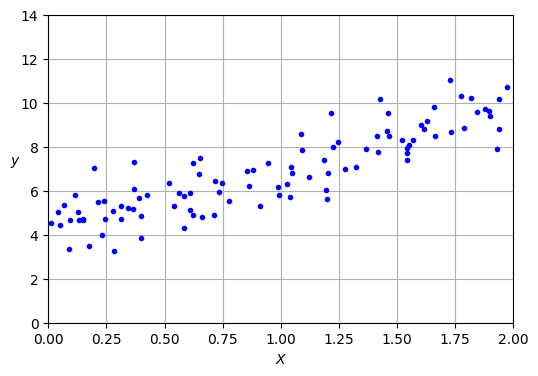

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$X$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 14])
plt.grid()
plt.show()

In [ ]:
#Define the output as a linear combination of features
def Predict(X, weights, bias):
    return np.dot(X, weights) + bias

#Define the Linear Regression Function
def LinearRegressionGD(X, y, eta=0.1, num_epochs=50):
    num_samples = X.shape[0]
    num_features = X.shape[1]

    if num_features == 1:
        X.reshape((1,num_samples))

    weights = np.random.normal(loc=0.0, scale=0.01, size=num_features)
    bias = np.array([0.])

    losses = []

    # Gradient descent
    for epoch in range(num_epochs):
        output = Predict(X, weights, bias)

        for k in range(num_features):
            gradMSE = 0.0
            for i in range(num_samples):
                gradMSE += (output[i] - y[i])*X[i,k]
            gradMSE *= (2.0/num_samples)
            weights[k] -= eta*gradMSE

        bias_gradMSE = 0.0
        for i in range(num_samples):
            bias_gradMSE += (output[i] - y[i])
        bias_gradMSE *= (2.0/num_samples)
        bias -= eta*bias_gradMSE

        loss = np.mean((output - y)**2)
        losses.append(loss)

    return weights, bias, losses


## Perform linear regression

/tmp/ipykernel_11956/2051767411.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  weights[k] -= eta*gradMSE


epoch:  0 loss:  50.00663597185707
epoch:  10 loss:  46.4013115575229
epoch:  20 loss:  43.09297412612903
epoch:  30 loss:  40.05758095553811
epoch:  40 loss:  37.27301760253825
epoch:  50 loss:  34.718943977860484
epoch:  60 loss:  32.37665267903497
epoch:  70 loss:  30.22893860611068
epoch:  80 loss:  28.25997896276411
epoch:  90 loss:  26.45522281666461
epoch:  100 loss:  24.801289458637132
epoch:  110 loss:  23.285874860616655
epoch:  120 loss:  21.897665588039164
epoch:  130 loss:  20.62625957354066
epoch:  140 loss:  19.462093205992478
epoch:  150 loss:  18.396374232309515
epoch:  160 loss:  17.421020009427103
epoch:  170 loss:  16.528600680624926
epoch:  180 loss:  15.71228688423637
epoch:  190 loss:  14.965801633950129
epoch:  200 loss:  14.283376038602068
epoch:  210 loss:  13.659708555766437
epoch:  220 loss:  13.089927497766825
epoch:  230 loss:  12.569556531106757
epoch:  240 loss:  12.094482930919865
epoch:  250 loss:  11.660928371002687
epoch:  260 loss:  11.2654220474482

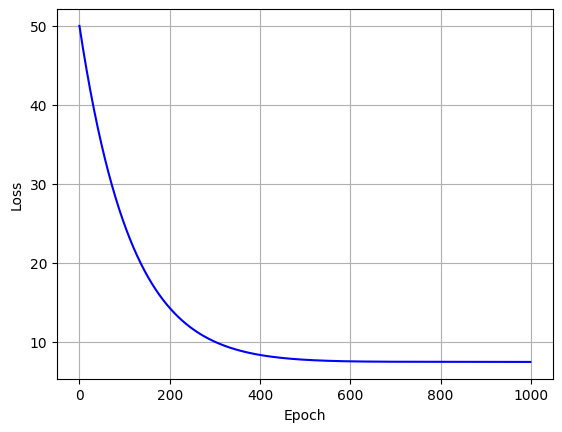

In [ ]:
weightsGD, biasGD, lossesGD = LinearRegressionGD(X, y, num_epochs=1000, eta=0.001)

#Print epoch vs loss
epochs = np.arange(len(lossesGD))
for i in range(len(epochs)):
  if i%10 == 0:
    print("epoch: ",epochs[i],"loss: ",lossesGD[i])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(epochs, lossesGD, 'b-')
plt.grid()

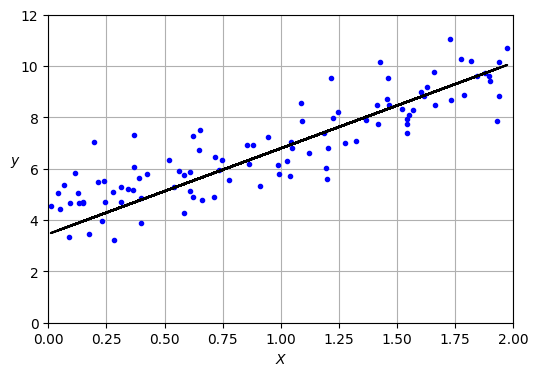

In [ ]:
outputGD = Predict(X, weightsGD, biasGD)
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X, outputGD, 'k')
plt.xlabel("$X$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 12])
plt.grid()
plt.show()

# Stochastic Gradient Descent

In [ ]:
#Function to randomly shuffle dataset
def RandShuffle(X,y):
    import random
    num_samples = X.shape[0]
    ind_list = list(range(num_samples))
    random.shuffle(ind_list)
    X  = X[ind_list, :]
    y = y[ind_list,]

def LinearRegressionSGD(X, y, eta=0.002, num_epochs=50):
    num_samples = X.shape[0]
    num_features = X.shape[1]

    if num_features == 1:
        X.reshape((1,num_samples))

    weights = np.random.normal(loc=0.0, scale=0.01, size=num_features)
    bias = np.array([0.])

    losses = []

    for epoch in range(num_epochs):
        RandShuffle(X,y)
        output = Predict(X, weights, bias)

        for k in range(num_features):
            for i in range(num_samples):
                gradMSE = 2.0 * (output[i] - y[i])*X[i,k]
                weights[k] -= eta*gradMSE

        for i in range(num_samples):
            bias_gradMSE = 2.0 * (output[i] - y[i])
            bias -= eta*bias_gradMSE

        loss = np.mean((output - y)**2)
        losses.append(loss)

    return weights, bias, losses

(100, 1) (100, 1)


/tmp/ipykernel_11956/244181294.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  weights[k] -= eta*gradMSE


epoch:  0 loss:  49.8221264082017
epoch:  10 loss:  24.435323320769626
epoch:  20 loss:  14.022510733921477
epoch:  30 loss:  9.864006500330314
epoch:  40 loss:  8.273703642792727
epoch:  50 loss:  7.70847218061339
epoch:  60 loss:  7.532380229498754
epoch:  70 loss:  7.490135508873754
epoch:  80 loss:  7.483881619514642
epoch:  90 loss:  7.4793518868281215
epoch:  100 loss:  7.466922856697614
epoch:  110 loss:  7.445794351579977
epoch:  120 loss:  7.417796627314991
epoch:  130 loss:  7.385128068135047
epoch:  140 loss:  7.349645433688024
epoch:  150 loss:  7.312731286312982
epoch:  160 loss:  7.275350226184539
epoch:  170 loss:  7.238147336012436
epoch:  180 loss:  7.201539198432896
epoch:  190 loss:  7.165784939527668
epoch:  200 loss:  7.131037676890919
epoch:  210 loss:  7.0973803230882115
epoch:  220 loss:  7.064849928489819
epoch:  230 loss:  7.033453992722582
epoch:  240 loss:  7.003181288520168
epoch:  250 loss:  6.974008993037582
epoch:  260 loss:  6.9459073583818025
epoch:  2

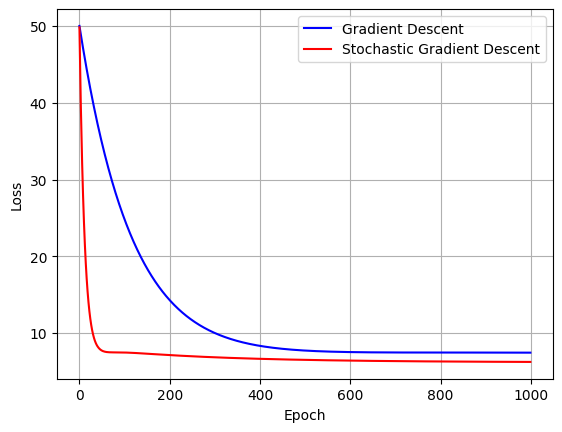

In [ ]:
print(X.shape,y.shape)

weightsSGD, biasSGD, lossesSGD = LinearRegressionSGD(X, y, num_epochs=1000, eta=0.0001)

epochs = np.arange(len(lossesSGD))
for i in range(len(epochs)):
  if i%10 == 0:
    print("epoch: ",epochs[i],"loss: ",lossesSGD[i])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(epochs, lossesGD, 'b-',label = 'Gradient Descent')
plt.plot(epochs, lossesSGD, 'r-',label = 'Stochastic Gradient Descent')
plt.grid()
plt.legend()

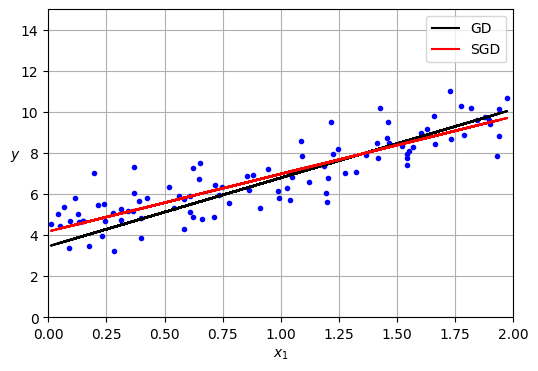

In [ ]:
outputSGD = Predict(X, weightsSGD, biasSGD)
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X, outputGD, 'k', label='GD')
plt.plot(X, outputSGD, 'r', label='SGD')
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.legend()
plt.grid()
plt.show()

# Solubility prediction

### Collect the data from solubility database

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/courses_@IITD/ML4Chem_CML7211/solubility_data.csv")
df.head(10)

Mounted at /content/drive


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1
5,benzothiazole,-2.733,2,135.191,0,2,0,12.89,-1.50,c2ccc1scnc1c2
6,"2,2,4,6,6'-PCB",-6.545,1,326.437,0,2,1,0.00,-7.32,Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl
7,Estradiol,-4.138,1,272.388,2,4,0,40.46,-5.03,CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O
8,Dieldrin,-4.533,1,380.913,0,5,0,12.53,-6.29,ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl
9,Rotenone,-5.246,1,394.423,0,5,3,63.22,-4.42,COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C


In [ ]:
X = df[['Molecular Weight','Number of H-Bond Donors','Number of Rings','Number of Rotatable Bonds','Polar Surface Area']].to_numpy()
y = df[['measured log solubility in mols per litre']].to_numpy()

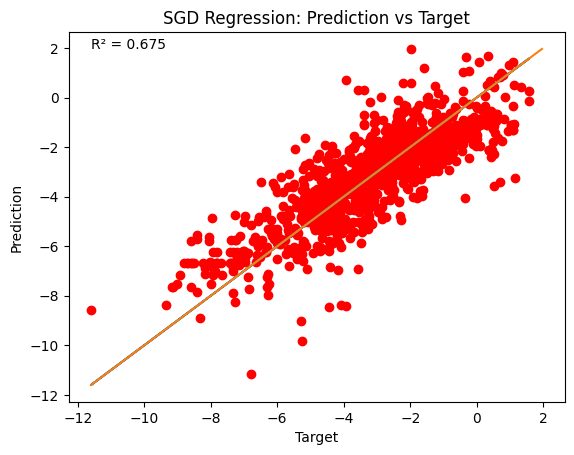

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

model = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-5,
                 penalty=None,
                 eta0=0.01,
                 learning_rate='constant',
                 random_state=42)
)

# Fit model
model.fit(X, y.ravel())

# Predictions
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate R2 score
R2 = r2_score(y,y_predict)
min_val = min(y.min(), y_predict.min())
max_val = max(y.max(), y_predict.max())
plt.plot([min_val, max_val], [min_val, max_val])

# Labels
plt.xlabel('Target')
plt.ylabel('Prediction')
plt.title('SGD Regression: Prediction vs Target')

plt.text(min_val, max_val, f'R² = {R2:.3f}')
plt.show()

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 31.2 MB/s eta 0:00:00


In [ ]:
# Extract SMILES as a list
smiles_list = df["smiles"].tolist()
print(smiles_list[:5])

['OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', 'Cc1occc1C(=O)Nc2ccccc2', 'CC(C)=CCCC(C)=CC(=O)', 'c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43', 'c1ccsc1']


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

def featurize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    features = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol)
    ]
    return np.array(features)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


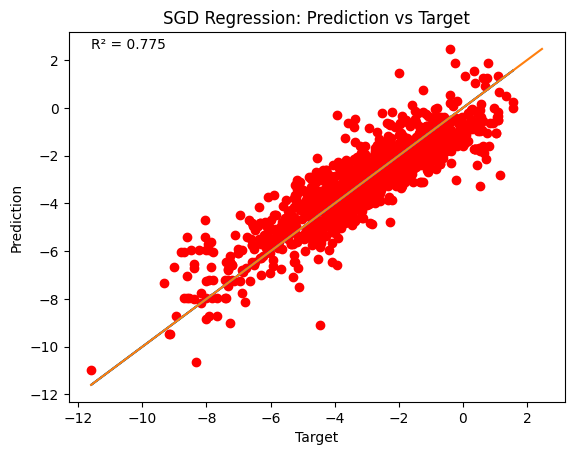

In [ ]:
X = np.array([featurize(s) for s in smiles_list])  # training SMILES
#y = df[['measured log solubility in mols per litre']].to_numpy()

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import learning_curve

model = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, random_state=42)
)

model.fit(X, y)

# Predictions
y_predict = model.predict(X)

plt.scatter(y,y_predict,color='r')
plt.plot(y,y)

#calculate R2 score
R2 = r2_score(y,y_predict)
min_val = min(y.min(), y_predict.min())
max_val = max(y.max(), y_predict.max())
plt.plot([min_val, max_val], [min_val, max_val])

# Labels
plt.xlabel('Target')
plt.ylabel('Prediction')
plt.title('SGD Regression: Prediction vs Target')

plt.text(min_val, max_val, f'R² = {R2:.3f}')
plt.show()


In [ ]:
def predict_solubility(smiles, model):
    try:
        x = featurize(smiles).reshape(1, -1)
        pred = model.predict(x)
        return float(pred[0])
    except:
        return "Invalid SMILES"

Enter SMILES: c1ccccc1O


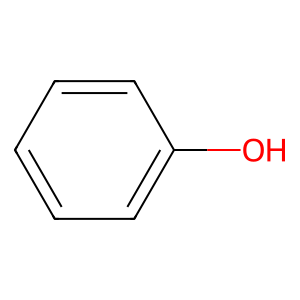

Phenol: -1.608


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

smiles = input("Enter SMILES: ")

# Create mapping
smiles_to_name = dict(zip(df["smiles"], df["Compound ID"]))

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    print("Invalid SMILES")
else:
    sol = predict_solubility(smiles, model)

    # Get name if available
    name = smiles_to_name.get(smiles, "Unknown molecule")
    img = Draw.MolToImage(mol)
    display(img)
    print(f"{name}: {sol:.3f}")

In [ ]:
test_smiles = {
    "Ethanol": "CCO",
    "Benzene": "c1ccccc1",
    "Acetic acid": "CC(=O)O"
}

for name, s in test_smiles.items():
    print(name,":", predict_solubility(s, model))

Ethanol : -0.15305266921937255
Benzene : -1.6092168881502718
Acetic acid : -0.47126467212238765
